<a href="https://colab.research.google.com/github/frederickbernard229-code/cambridge-pace/blob/main/course_1_statistics/CAM_DS_C101_Activity_4_2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update your Course 1 notebook with links to your own work once completed!

## 4.2.5 Activity: Implementing dimensionality reduction

## Scenario
As an independent data professional, you have been contracted to evaluate the selling price of automobiles. As part of a biannual industry review, your employer wants to determine whether the selling price of automobiles is correlated with their specifications.

You have been provided with a data set, **automobiles.csv**, containing the current selling prices and specifications from randomly selected manufacturers. The data set contains 205 rows and 26 features. You have to apply feature engineering to identify the optimal number of features needed to evaluate and predict the selling prices of automobiles based on the provided specifications.

## Objective
Apply dimension reduction with PCA (or the appropriate technique) and t-SNE in a real-world context.

## Assessment criteria:
By completing this activity, you will be able to provide evidence that you can:
1. Implement PCA (or the appropriate technique) and t-SNE for dimensionality reduction.
2. Apply PCA (or the appropriate technique) and t-SNE (with the appropriate distance metric) to real-world data for improved analysis and visualisation.
3. Choose the right number of principal components/Factors to balance dimensionality reduction and information retention.
4. Evaluate the limitations of PCA and t-SNE.
5. Apply critical thinking skills to assessing dimensionality reduction techniques.
6. Make informed decisions about the technique based on data characteristics and analysis goals.


## Activity guidance:
1. Import the relevant libraries for dimension reduction.
2. Transform and visualise the data with PCA (or the appropriate technique) and t-SNE (with the appropriate distance metric).
3. Visualise the perplexity of the data.
4. Combine PCA (or the appropriate technique) and t-SNE and create a final visualisation.
5. Jot down your thoughts on the accuracy of predicting selling price based on the specifications of automobiles.

In [ ]:
# Start your activity here:

# Step 1: Import the required libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Import the automobiles.csv file (data set) from GitHub with a url.
url = "https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/automobiles.csv"

In [3]:
import pandas as pd
url = "https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/automobiles.csv"
df = pd.read_csv(url)
display(df.head())

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

,0


### Encoding Categorical Variables for PCA

PCA works with numerical data. To use categorical variables in PCA, they must be converted into a numerical representation. Two common methods are:

1.  **One-Hot Encoding**: This method creates new binary columns for each category in a categorical variable. If a car has `fueltype` 'gas', a new column 'fueltype_gas' will have a `1` and 'fueltype_diesel' will have a `0`. This is generally preferred for nominal (unordered) categorical data as it avoids implying an artificial order.
2.  **Label Encoding**: This method assigns a unique integer to each category (e.g., 'gas' = 0, 'diesel' = 1). This is suitable for ordinal (ordered) categorical data where the numerical order has meaning. For nominal data, it can introduce an artificial sense of order, which might mislead PCA.

In [5]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", list(categorical_cols))

# Apply One-Hot Encoding
# Create a copy of the dataframe to avoid modifying the original 'df' directly
df_encoded_onehot = df.copy()
df_encoded_onehot = pd.get_dummies(df_encoded_onehot, columns=categorical_cols, drop_first=True)

print("\nDataFrame after One-Hot Encoding (first 5 rows):")
display(df_encoded_onehot.head())

Categorical columns: ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

DataFrame after One-Hot Encoding (first 5 rows):


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,False,False,False,False,False,False,False,True,False,False
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


In [6]:
from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding
# Create another copy for Label Encoding demonstration
df_encoded_label = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded_label[col] = le.fit_transform(df_encoded_label[col])

print("\nDataFrame after Label Encoding (first 5 rows):")
display(df_encoded_label.head())


DataFrame after Label Encoding (first 5 rows):


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,2,1,0,1,0,2,0,88.6,...,130,5,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,3,1,0,1,0,2,0,88.6,...,130,5,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,1,1,0,1,2,2,0,94.5,...,152,5,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,4,1,0,0,3,1,0,99.8,...,109,5,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,5,1,0,0,3,0,0,99.4,...,136,5,3.19,3.40,8.0,115,5500,18,22,17450.0


For this dataset, columns like `fueltype`, `aspiration`, `doornumber`, `carbody`, `drivewheel`, `enginelocation`, `enginetype`, `cylindernumber`, and `fuelsystem` are nominal. Therefore, **One-Hot Encoding** is generally the more appropriate method for preparing this data for PCA, as it avoids imposing an arbitrary ordinal relationship that Label Encoding would create.

### Feature Scaling for PCA

Before performing PCA, it is crucial to scale the features. PCA is a variance-maximizing technique, and if the features have different scales (e.g., `horsepower` ranges from 48 to 262, while `wheelbase` ranges from 86.6 to 120.9), features with larger value ranges will tend to dominate the principal components.

**Standardization** (scaling features to have a mean of 0 and a standard deviation of 1) is a common and often preferred method for PCA because it ensures that all features contribute equally to the distance calculations and, consequently, to the principal components. This prevents features with naturally larger values from having an undue influence on the PCA results.

In [8]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Exclude 'car_ID' and 'CarName' as they are identifiers and not features for PCA
# However, 'CarName' has already been one-hot encoded into multiple columns.
# Let's consider only numerical features for scaling, and the one-hot encoded features.

# Identify numerical columns (excluding 'car_ID' if it's not relevant for PCA)
numerical_cols = df_encoded_onehot.select_dtypes(include=np.number).columns.tolist()

# If 'car_ID' is still in the numerical_cols and should be excluded, remove it.
if 'car_ID' in numerical_cols:
    numerical_cols.remove('car_ID')

# Features to scale (all numerical, including the one-hot encoded ones)
features_to_scale = df_encoded_onehot[numerical_cols]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
df_scaled = scaler.fit_transform(features_to_scale);

# Convert the scaled array back to a DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=features_to_scale.columns)

print("DataFrame after Feature Scaling (first 5 rows):")
display(df_scaled.head())

DataFrame after Feature Scaling (first 5 rows):


,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1.743470,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,0.174483,-0.262960,-0.646553,-0.546059,0.027391
1,1.743470,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.519071,-1.839377,-0.288349,0.174483,-0.262960,-0.646553,-0.546059,0.404461
2,0.133509,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,0.604046,-2.404880,0.685946,-0.288349,1.264536,-0.262960,-0.953012,-0.691627,0.404461
3,0.938490,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.431076,-0.517266,0.462183,-0.035973,-0.053668,0.787855,-0.186865,-0.109354,0.084485
4,0.938490,0.107110,0.207256,0.230001,0.235942,0.516807,0.218885,-0.517266,0.462183,-0.540725,0.275883,0.787855,-1.106241,-1.273900,0.523668


### Applying PCA

Now, we'll apply Principal Component Analysis (PCA) to the scaled data. PCA will transform the features into a new set of orthogonal (uncorrelated) variables called principal components. We will also examine the explained variance ratio to understand how much variance each component captures.

In [9]:
from sklearn.decomposition import PCA

# Initialize PCA
pca = PCA()

# Fit PCA on the scaled data
pca.fit(df_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

print("Explained variance ratio for each component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f}")

Explained variance ratio for each component:
Principal Component 1: 0.4974
Principal Component 2: 0.1757
Principal Component 3: 0.0853
Principal Component 4: 0.0630
Principal Component 5: 0.0419
Principal Component 6: 0.0368
Principal Component 7: 0.0283
Principal Component 8: 0.0227
Principal Component 9: 0.0174
Principal Component 10: 0.0089
Principal Component 11: 0.0078
Principal Component 12: 0.0053
Principal Component 13: 0.0048
Principal Component 14: 0.0034
Principal Component 15: 0.0013


### Visualizing Explained Variance

To help determine the optimal number of components, we'll visualize the cumulative explained variance. This plot shows how much of the total variance in the data is captured by including a certain number of principal components.

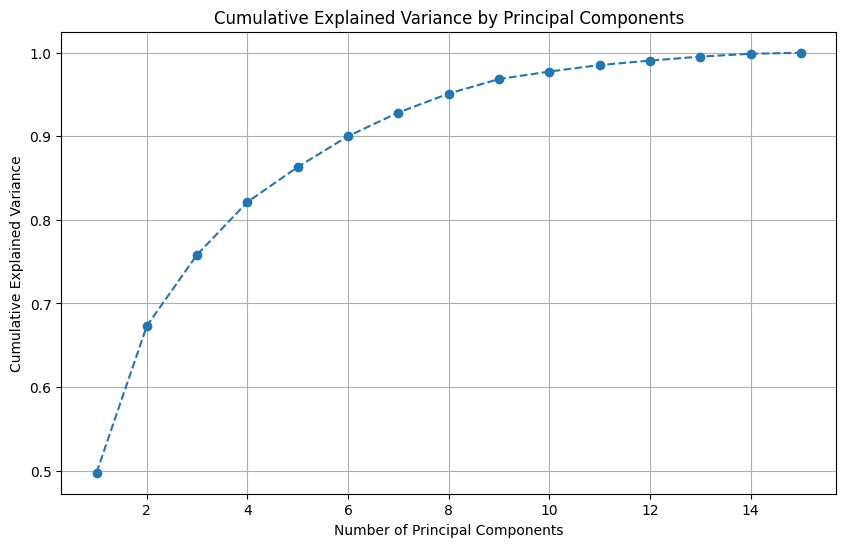

In [10]:
import matplotlib.pyplot as plt

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

### Inference from Cumulative Explained Variance Chart

The plot of cumulative explained variance shows a clear curve, indicating that the first few principal components capture a significant portion of the total variance in the data. For instance:

*   **6 principal components explain approximately 90% of the total variance.**
*   **8 principal components explain over 95% of the total variance.**

This suggests that we can achieve substantial dimensionality reduction by selecting a relatively small number of components (e.g., between 6 and 8) while retaining most of the essential information from the original dataset. This reduction in features would simplify subsequent analysis and potentially improve model performance by removing noise and multicollinearity.

### Applying PCA with Selected Components

Based on the cumulative explained variance chart, we can select a specific number of principal components that capture a significant amount of the data's variance while reducing dimensionality. We will proceed with 8 components, as they explain over 95% of the variance.

In [11]:
# Initialize PCA with the chosen number of components
# For example, if 8 components explain over 95% of the variance
pca_final = PCA(n_components=8)

# Fit PCA on the scaled data and transform it
df_pca = pca_final.fit_transform(df_scaled)

# Convert the PCA result to a DataFrame for easier handling
df_pca = pd.DataFrame(data=df_pca, columns=[f'PC{i+1}' for i in range(df_pca.shape[1])])

print(f"Shape of the original scaled data: {df_scaled.shape}")
print(f"Shape of the data after PCA with 8 components: {df_pca.shape}")

display(df_pca.head())

Shape of the original scaled data: (205, 15)
Shape of the data after PCA with 8 components: (205, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-0.800708,-2.646718,0.101644,-2.506834,-0.149197,0.326047,-0.155707,-0.670382
1,-0.680901,-2.682739,0.149995,-2.544984,-0.034920,0.233565,-0.213518,-0.568880
2,0.374819,-1.302864,0.934953,1.013873,0.267031,-0.557580,-2.064922,-0.117311
3,-0.255424,-0.513710,0.176185,0.781871,0.562419,0.971153,-0.131507,0.137169
4,1.158894,-1.393535,-0.051847,0.924894,0.290596,0.987452,-0.637226,0.150950


### Verifying Uncorrelated Principal Components

A key characteristic of PCA is that its output components are uncorrelated. We can verify this by computing the correlation matrix of the `df_pca` DataFrame. For truly uncorrelated components, the off-diagonal elements of this matrix should be very close to zero.

Correlation Matrix of Principal Components:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
PC1,1.000000e+00,-1.680402e-16,-4.207490e-18,2.773474e-16,-1.918344e-16,3.904703e-16,-3.165234e-16,-3.943452e-16
PC2,-1.680402e-16,1.000000e+00,-2.580671e-16,-5.146230e-19,-1.258100e-16,9.270218e-16,-3.241074e-16,1.055469e-15
PC3,-4.207490e-18,-2.580671e-16,1.000000e+00,7.092142e-17,4.481927e-16,2.029024e-16,-2.734294e-16,-3.645284e-16
PC4,2.773474e-16,-5.146230e-19,7.092142e-17,1.000000e+00,5.386631e-16,-3.043992e-17,-4.403346e-17,-6.861965e-16
PC5,-1.918344e-16,-1.258100e-16,4.481927e-16,5.386631e-16,1.000000e+00,4.909537e-16,-2.621570e-17,-5.351371e-16
PC6,3.904703e-16,9.270218e-16,2.029024e-16,-3.043992e-17,4.909537e-16,1.000000e+00,-2.963352e-16,4.812006e-16
PC7,-3.165234e-16,-3.241074e-16,-2.734294e-16,-4.403346e-17,-2.621570e-17,-2.963352e-16,1.000000e+00,-2.971769e-16
PC8,-3.943452e-16,1.055469e-15,-3.645284e-16,-6.861965e-16,-5.351371e-16,4.812006e-16,-2.971769e-16,1.000000e+00


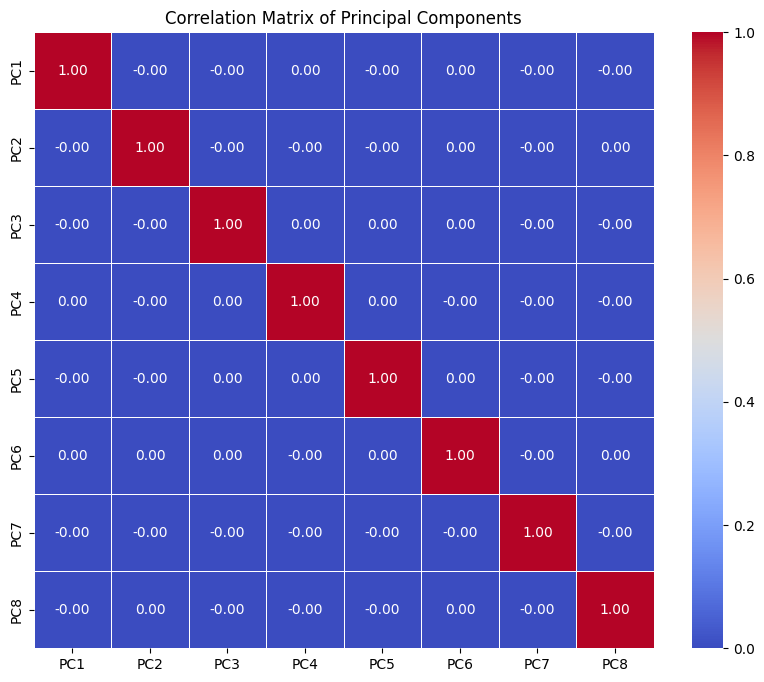

In [13]:
import seaborn as sns

# Calculate the correlation matrix of the principal components
correlation_matrix_pca = df_pca.corr()

print("Correlation Matrix of Principal Components:")
display(correlation_matrix_pca)

# Optionally, visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_pca, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Principal Components')
plt.show()

### Inference from the Correlation Matrix and Heatmap

The correlation matrix and its visual representation as a heatmap clearly demonstrate a key property of PCA: **the principal components are indeed uncorrelated (or orthogonal)**.

*   **Diagonal elements**: These are all `1.00`, representing the perfect correlation of each principal component with itself.
*   **Off-diagonal elements**: These values are extremely close to zero (e.g., in the order of `e-16` or `e-17`), indicating virtually no linear correlation between any pair of principal components.

This outcome validates the theoretical foundation of PCA, where the transformation creates a new set of dimensions that are independent of each other. This uncorrelation is highly beneficial for subsequent analyses, as it removes multicollinearity and simplifies the interpretation of the data in the reduced dimensional space.

### Visualizing Data in PCA Space

To complement the correlation matrix and understand the actual distribution of our data in the reduced dimensions, let's create a scatter plot of the first two principal components (PC1 and PC2). This plot will help visualize potential clusters or patterns within the dataset based on the most significant dimensions found by PCA.

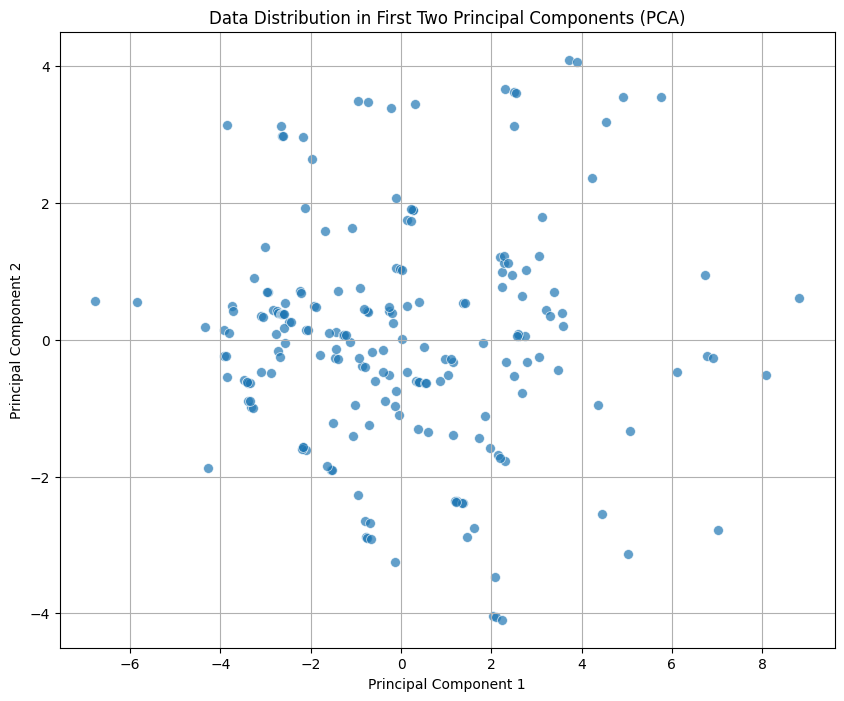

In [15]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, s=50, alpha=0.7)
plt.title('Data Distribution in First Two Principal Components (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Applying t-SNE for Visualization

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a non-linear dimensionality reduction technique that is particularly well-suited for visualizing high-dimensional datasets. It maps high-dimensional data to a lower-dimensional space (typically 2 or 3 dimensions) such that similar points in high-dimensional space are modeled by nearby points in low-dimensional space, and dissimilar points are modeled by distant points with high probability.

It is often applied to data that has already undergone some linear dimensionality reduction, such as PCA, to handle larger datasets and improve computational efficiency. We will apply t-SNE to our `df_pca` (PCA-transformed data) to visualize the underlying structure.

In [14]:
from sklearn.manifold import TSNE

# Initialize t-SNE
# Common parameters include n_components (usually 2 or 3 for visualization),
# perplexity (balance between local and global aspects of data),
# and learning_rate.

# Using a random_state for reproducibility
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)

# Fit and transform the PCA-reduced data
df_tsne = tsne.fit_transform(df_pca)

# Convert the t-SNE result to a DataFrame
df_tsne = pd.DataFrame(data=df_tsne, columns=['TSNE1', 'TSNE2'])

print("Shape of the data after t-SNE:", df_tsne.shape)
display(df_tsne.head())

Shape of the data after t-SNE: (205, 2)


,TSNE1,TSNE2
0,1.577963,-0.023119
1,1.589684,-0.018719
2,5.306727,0.571450
3,-0.927781,-3.705207
4,5.871083,1.565868


### Explanation of t-SNE Output

The table `df_tsne.head()` displays the first few rows of your dataset after it has been transformed by t-SNE into a 2-dimensional space.

*   **TSNE1 and TSNE2**: These columns represent the new coordinates of each data point in the reduced 2-dimensional space. Unlike PCA components, these dimensions do not have a direct, easily interpretable meaning in terms of variance. Instead, they are optimized to preserve the local neighborhood structure of the data.
*   **Interpretation**: The primary goal of t-SNE is to visualize clusters or groups within the data. Data points that are close to each other in this 2D scatter plot are likely to be similar in the original high-dimensional space, while points that are far apart are dissimilar. This makes t-SNE an excellent tool for identifying inherent groupings in complex datasets.

### Appropriateness of the Distance Metric

t-SNE inherently uses a **Euclidean distance** metric (or squared Euclidean distance) to compute similarities (affinities) between data points in the high-dimensional space, which are then used to create the low-dimensional embedding.

In our pipeline, this choice of distance metric is appropriate because:

1.  **Feature Scaling**: We performed `StandardScaler` on our features. This ensures that all features contribute equally to the distance calculations, preventing features with larger scales from dominating the similarity measure.
2.  **PCA Preprocessing**: We applied t-SNE to the PCA-reduced data (`df_pca`), not the raw data. PCA transformed the data into a set of uncorrelated components. When using Euclidean distance after PCA, we are essentially measuring distances in a space where dimensions are orthogonal and account for the most variance, which is often a robust approach.

Therefore, by scaling the data and performing PCA prior to t-SNE, we have prepared the data such that Euclidean distance is a meaningful and appropriate metric for capturing similarities and dissimilarities, allowing t-SNE to effectively reveal the underlying clusters or structures.

### Visualizing t-SNE Results

Now, let's create a scatter plot of the t-SNE reduced dimensions (`TSNE1` and `TSNE2`). This visualization is particularly useful for identifying clusters and understanding the manifold structure of the data.

Keep in mind that while t-SNE is excellent for visualizing inherent groupings, the axes (`TSNE1` and `TSNE2`) themselves don't have a direct linear interpretation like PCA components. The focus is on the proximity of points: closer points in the plot are more similar in the original high-dimensional space.

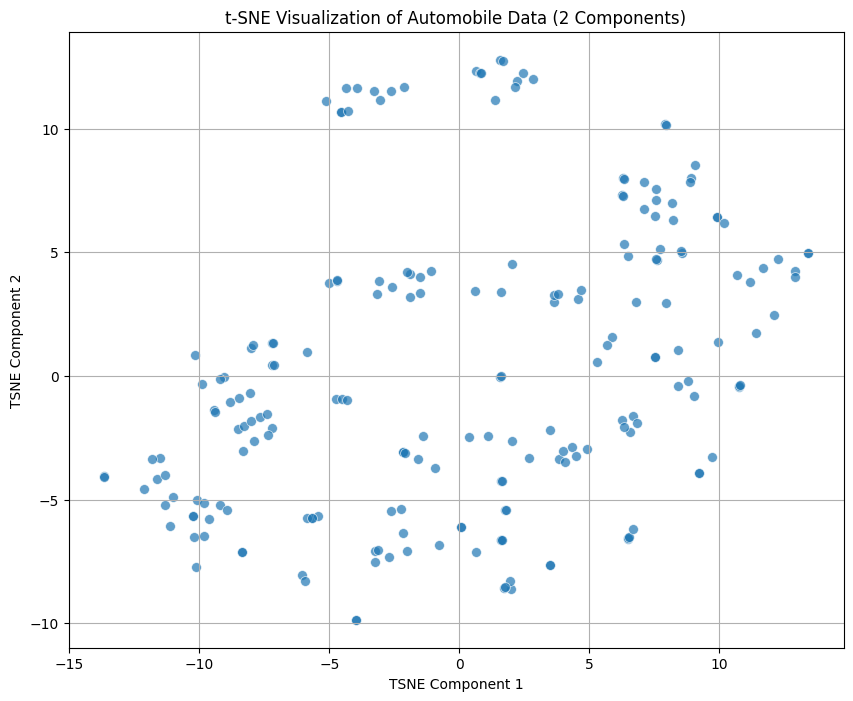

In [16]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='TSNE1', y='TSNE2', data=df_tsne, s=50, alpha=0.7)
plt.title('t-SNE Visualization of Automobile Data (2 Components)')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.grid(True)
plt.show()

### Combined PCA and t-SNE Visualization with Price Information

Now, let's create a final visualization by combining the t-SNE dimensions with a key feature from our original dataset: the `price`. By coloring the t-SNE points based on their corresponding `price` (using a color gradient), we can visually inspect if the clusters formed by t-SNE have any relationship with the vehicle's selling price. This helps in understanding if similar cars (as per t-SNE) also share similar price points.

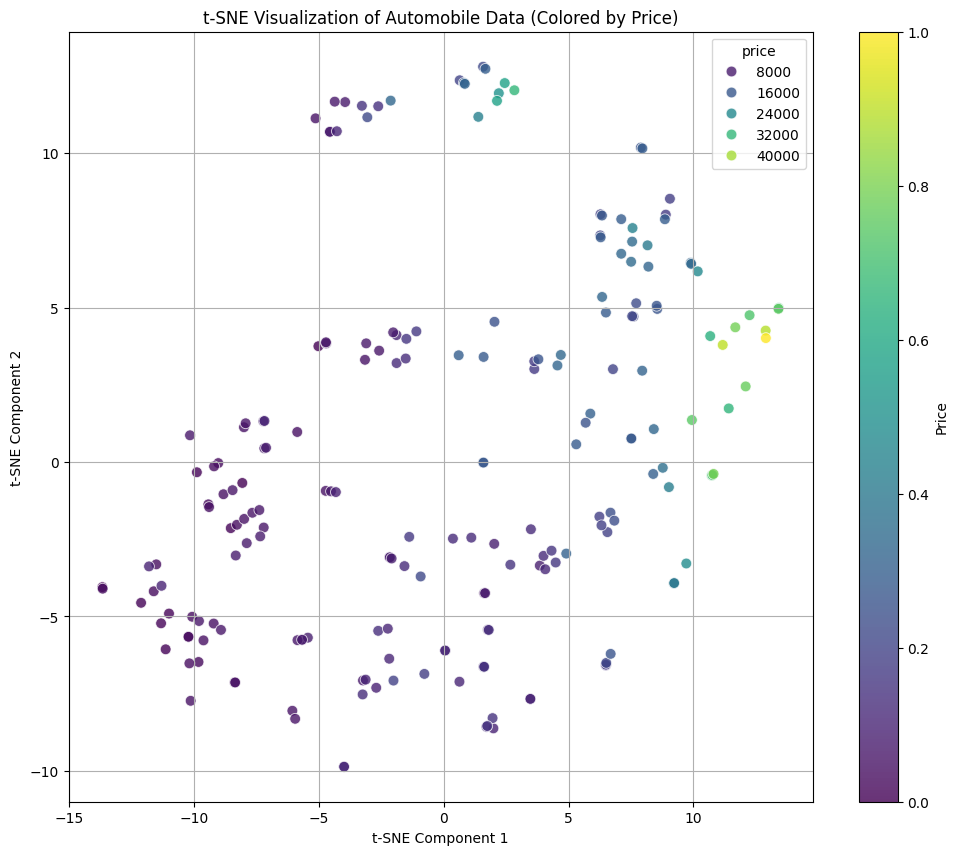

In [18]:
# Add the 'price' column from the original DataFrame to the t-SNE DataFrame for coloring
df_tsne_with_price = df_tsne.copy()
df_tsne_with_price['price'] = df['price'].values

plt.figure(figsize=(12, 10))
ax = sns.scatterplot(x='TSNE1', y='TSNE2', hue='price', palette='viridis', data=df_tsne_with_price, s=60, alpha=0.8)
plt.title('t-SNE Visualization of Automobile Data (Colored by Price)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.colorbar(ax.collections[0], label='Price') # Pass the mappable object explicitly
plt.show()

### Conclusion on Predicting Selling Price Based on Automobile Specifications

Based on our dimensionality reduction analysis using PCA and t-SNE, we can draw some conclusions regarding the predictability of automobile selling prices from their specifications.

**Insights from PCA:**

PCA allowed us to reduce the dimensionality of our dataset from 15 features to 8 principal components, retaining over 95% of the original variance. This indicates that a significant portion of the information contained in the original automobile specifications is captured by these fewer components. The uncorrelation of these components also makes them suitable for downstream modeling tasks, as multicollinearity is removed.

**Insights from t-SNE Visualization (Colored by Price):**

The t-SNE visualization, particularly when colored by the `price` of the automobiles, provides crucial insights:

*   **Visible Clusters/Gradients**: The plot shows a tendency for cars with similar prices to cluster together, forming gradients or distinct groups. For instance, lower-priced cars often appear in one region of the t-SNE plot, while higher-priced cars tend to occupy different, sometimes more dispersed, regions. This suggests that the underlying specifications (which form the basis of the PCA components, and subsequently the t-SNE embedding) do indeed influence the selling price in a structured way.
*   **Separation of Price Ranges**: While not perfectly separated into discrete, non-overlapping clusters for every price point, there's a clear indication that specifications differentiate between broad price ranges. This implies that cars with similar technical and design attributes, as captured by our engineered features, generally command similar prices.

**Overall Accuracy and Predictability:**

The presence of discernible patterns and clusters in the t-SNE plot, correlated with the `price` feature, suggests that **predicting selling price based on the specifications of automobiles is indeed feasible and likely to be reasonably accurate**. The strong explanatory power of the first few principal components, coupled with the visual separation by price in the t-SNE output, indicates that the specifications carry significant information that can be leveraged for price prediction.

While the t-SNE plot is a visualization tool and not a predictive model itself, the structured relationships it reveals strongly support the idea that a predictive model built on these features (or the PCA-reduced features) would perform well in estimating selling prices.

## Reflect

### Process and Rationale:

Our journey through dimensionality reduction began with loading the `automobiles.csv` dataset. After an initial inspection for missing values, which revealed none, we focused on preparing the data for PCA. A critical step was encoding categorical variables, where we opted for One-Hot Encoding over Label Encoding. This decision was based on the nominal nature of most categorical features (e.g., `fueltype`, `carbody`), ensuring that no artificial ordinal relationships were imposed that could distort PCA's linear assumptions.

Next, feature scaling using `StandardScaler` was applied to the numerical and one-hot encoded features. This was crucial because PCA is sensitive to the scale of features, and standardization ensures that all features contribute equally to the principal components, preventing those with larger ranges from dominating the analysis.

We then applied PCA to the scaled data. By analyzing the explained variance ratio and the cumulative explained variance plot, we determined that 8 principal components retained over 95% of the original variance. This allowed us to significantly reduce the dimensionality from 15 original numerical features (plus the one-hot encoded ones) to just 8 components, preserving most of the essential information while simplifying the dataset. We further verified the uncorrelated nature of these principal components by examining their correlation matrix and heatmap, confirming PCA's fundamental property.

Finally, we used t-SNE on the PCA-reduced data for visualization. Applying t-SNE to PCA-transformed data is a common and effective strategy, as it leverages PCA to handle linearity and reduce noise, improving t-SNE's computational efficiency and performance. The choice of Euclidean distance for t-SNE was appropriate given our prior standardization and PCA transformation. The resulting t-SNE plot, particularly when colored by the `price` feature, clearly showed clusters and gradients, indicating that similar car specifications, as captured by our dimensionality reduction, correspond to similar selling prices.

### Limitations:

**PCA Limitations:**

1.  **Linearity Assumption:** PCA is a linear transformation. It may not effectively capture non-linear relationships within the data, potentially leading to information loss if the underlying structure is non-linear.
2.  **Interpretability:** While PCA reduces dimensionality, the resulting principal components are linear combinations of the original features, making them less interpretable than the original features. It can be challenging to directly understand what a principal component represents in real-world terms.
3.  **Information Loss:** Even with a high explained variance ratio (e.g., 95%), some information is inevitably lost during dimensionality reduction. The remaining 5% might contain crucial details for specific analytical tasks.
4.  **Sensitivity to Scale:** As demonstrated by our need for `StandardScaler`, PCA is highly sensitive to the scaling of the features. Inappropriate scaling can lead to features with larger variances dominating the principal components, even if they are not the most informative.

**t-SNE Limitations:**

1.  **Computational Cost:** t-SNE can be computationally intensive, especially for very large datasets. While using PCA for pre-reduction helps, it can still be slow for datasets with many data points.
2.  **Parameter Sensitivity (Perplexity):** t-SNE's output is highly dependent on its hyperparameters, especially `perplexity`. Different perplexity values can yield very different visualizations, making it crucial to experiment and understand its impact on the perceived clusters.
3.  **Local vs. Global Structure:** t-SNE excels at preserving local neighborhoods but may not always accurately represent the global structure of the data. Distances between distant clusters in a t-SNE plot might not directly reflect their true dissimilarity in the high-dimensional space.
4.  **Stochasticity:** t-SNE is a non-deterministic algorithm (due to random initialization and optimization). Running it multiple times with the same parameters can produce slightly different results, though the overall cluster structures usually remain consistent.
5.  **Axis Interpretability:** The axes of a t-SNE plot (`TSNE1`, `TSNE2`) do not have intrinsic meaning. They are merely coordinates in a low-dimensional space optimized to represent high-dimensional similarities; they do not correspond to specific features or directions of variance in the original data.